# 📊 SHAP Interpretation Report: RANDOM_FOREST
This notebook provides a post-hoc explanation of the model's predictions using **tree** SHAP.

---

### 🔍 What are SHAP Values?
**SHAP (SHapley Additive exPlanations)** decomposes a model's prediction into the contribution of each individual feature. 
* **Magnitude:** A larger absolute SHAP value means the feature had a bigger impact on the output.
* **Direction:** A positive SHAP value means the feature pushed the prediction *higher*, while a negative value pushed it *lower*.
* **Interpretation:** For any given sample, the sum of SHAP values plus the base value (average model output) equals the actual model prediction.

### 🧪 Methodology
**Tree SHAP** is an optimized algorithm for tree-based models (like Random Forest or XGBoost). It leverages the internal structure of the trees to calculate exact SHAP values significantly faster than model-agnostic methods.

---

### 📋 Metadata
**Model Architecture:** RANDOM_FOREST  
**Analysis Context:** tabular  
**Dataset Scope:** subset

---


In [1]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Data provided by the explainer
all_shap_dict = {0: [[0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.1435550561797753, -0.1435550561797753, 0.014110112359550559], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.06860562734013659, 0.05346615520152705, -0.39507178254166364], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.06860562734013659, 0.05346615520152705, -0.3950717825416636], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.06479771040915838, -0.3621473818104728, 0.024349671401314388], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.09100000000000003, -0.09100000000000003, -0.09100000000000001], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.34544293052944525, 0.048875748699339826, 0.023567181830105356], [0.041075471698113215, -0.15703773584905664, -0.1570377358490566], [-0.15199124513618678, 0.03098249027237354, -0.15199124513618678], [0.15592561886017053, 0.12329920586932436, 0.061258321337920855]], 1: [[0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, 0.33568181818181825, 0.14798380681818174], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.30794039036398807, -0.0038888888888888896, 0.06382927925287696], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.11100000000000002, -0.0038888888888888896, 0.08117460317460314], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, 0.0175, 0.06229303765072635], [-0.3627785135888274, -0.0038888888888888896, 0.1186674024777162], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, 0.0175, -0.15450000000000003], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, 0.0175, -0.11954866071428573], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, 0.0175, -0.333834375], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, 0.0175, -0.003053438413103444], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.11100000000000002, -0.07459595959595959, -0.04018181818181817], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, -0.0038888888888888896, 0.3461126884946653], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.1615686644769332, 0.0175, 0.06229303765072635], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.068334375, -0.07459595959595959, -0.21951619318181814], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [0.24524788701989497, -0.0038888888888888896, 0.4392124304404223], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3627785135888274, 0.0175, 0.09727851358882733], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.18957580281783012, 0.0175, 0.18128783354580613], [0.24524788701989497, 0.0175, 0.4178235415515334], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.1615686644769332, -0.0038888888888888896, 0.08368192653961526], [-0.3983722022658193, -0.0038888888888888896, 0.15426109115470818], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, 0.0175, -0.14778786337209304], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.09815977182539685], [0.068334375, 0.33568181818181825, 0.14798380681818174], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [-0.26244656158689655, -0.0038888888888888896, 0.01833545047578545], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.068334375, -0.0038888888888888896, -0.12639897448320414], [-0.3983722022658193, 0.0175, 0.1328722022658193], [-0.3983722022658193, 0.0175, 0.1328722022658193], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [0.24524788701989497, 0.0175, 0.4178235415515334], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.22333552242812182, 0.0175, 0.3247237996057764], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.07459595959595959, -0.21951619318181814], [-0.11100000000000002, -0.0038888888888888896, -0.13311111111111112], [0.068334375, -0.0038888888888888896, -0.3124454861111111], [0.068334375, -0.07459595959595959, -0.21951619318181814]]}
data_raw = np.array([[56, 68886, 34], [69, 77412, 50], [46, 54840, 14], [32, 52785, 8], [60, 80406, 36], [25, 37323, 3], [38, 33802, 9], [56, 81875, 38], [36, 59268, 16], [40, 29308, 6], [28, 25590, 5], [28, 58543, 9], [41, 59460, 11], [53, 78225, 24], [57, 49373, 16], [41, 51770, 12], [20, 15661, 0], [39, 23461, 3], [19, 42216, 1], [41, 31977, 2], [61, 63186, 40], [47, 58430, 12], [55, 47952, 17], [19, 48120, 0], [38, 49620, 3], [50, 60309, 21], [29, 16798, 1], [39, 77195, 14], [61, 37224, 7], [42, 33620, 7], [66, 85939, 48], [44, 56126, 11], [59, 49326, 18], [45, 28937, 9], [33, 30827, 8], [32, 42949, 4], [64, 53455, 5], [68, 74185, 25], [61, 66880, 33], [69, 59167, 44], [20, 42990, 1], [54, 77161, 36], [68, 47867, 32], [24, 29725, 4], [38, 83986, 20], [26, 37013, 5], [56, 41311, 5], [35, 67362, 15], [21, 40129, 3], [42, 48240, 10], [31, 48989, 13], [67, 80960, 29], [26, 43130, 7], [43, 64835, 22], [19, 26561, 0], [37, 18425, 2], [45, 71773, 18], [64, 96442, 30], [24, 49056, 4], [61, 44603, 35], [25, 53027, 7], [64, 82422, 30], [52, 53219, 5], [31, 49010, 1], [34, 27419, 10], [53, 24784, 3], [67, 68258, 14], [57, 21418, 5], [21, 30732, 1], [19, 36927, 0], [23, 38899, 5], [59, 93743, 37], [21, 30320, 2], [46, 95125, 24], [35, 32294, 1], [43, 51227, 14], [61, 40274, 10], [51, 34819, 7], [27, 45184, 9], [53, 26076, 4], [31, 36479, 5], [48, 52199, 25], [65, 43515, 3], [32, 34719, 2], [25, 26238, 3], [31, 34576, 0], [40, 41142, 19], [57, 40496, 11], [38, 61262, 14], [33, 41928, 0], [62, 52372, 25], [35, 52075, 13], [64, 73646, 37], [41, 36042, 4], [43, 27912, 10], [42, 38967, 3], [62, 26191, 12], [58, 34122, 2], [46, 49707, 0], [32, 41917, 5], [62, 40469, 9], [18, 15968, 0], [42, 46164, 4], [24, 44711, 6], [26, 16845, 1], [41, 53172, 12], [18, 30360, 0], [61, 70892, 39], [25, 37533, 1], [41, 37618, 19], [28, 43404, 0], [68, 105732, 36], [34, 28344, 8], [25, 48997, 0], [52, 49275, 8], [52, 25789, 10], [50, 35509, 14], [22, 42121, 2], [59, 82337, 29], [56, 49958, 30], [58, 28622, 4], [45, 67497, 27], [24, 27413, 3], [26, 29207, 1], [25, 34550, 5], [29, 45003, 4], [51, 67316, 10], [50, 35747, 8], [65, 72277, 33], [40, 47213, 11], [41, 20816, 2], [54, 88669, 34], [52, 38196, 0], [61, 64939, 39], [57, 56323, 21], [39, 46916, 7], [44, 62095, 10], [52, 49861, 13], [18, 39089, 0], [52, 41953, 29], [54, 83625, 34], [64, 63939, 20], [31, 49303, 4], [20, 46890, 0], [18, 28598, 0], [22, 37780, 2], [43, 39183, 13], [31, 59093, 9], [56, 26587, 3], [44, 31993, 24], [26, 43751, 8], [32, 21308, 1], [32, 27755, 7], [43, 43235, 7], [59, 89906, 38], [30, 52071, 7], [68, 43831, 13], [49, 48410, 31], [56, 101640, 37], [66, 82949, 32], [69, 58467, 22], [49, 79313, 30], [21, 22328, 2], [47, 22761, 0], [54, 74100, 24], [40, 66816, 16], [56, 68778, 32], [62, 34645, 1], [32, 29047, 13], [60, 45890, 39], [46, 52428, 7], [53, 22561, 5], [30, 43206, 5], [49, 44191, 2], [24, 60962, 6], [68, 98358, 50], [39, 40338, 7], [45, 61948, 9], [19, 33897, 1], [59, 31599, 14], [62, 89344, 28], [23, 46010, 0], [45, 64423, 19], [45, 40249, 6], [61, 76413, 26], [61, 104132, 35], [37, 30920, 5], [47, 84676, 24], [28, 43441, 0], [45, 25147, 4], [42, 65943, 22], [56, 108812, 32], [50, 18799, 3], [18, 19760, 0], [44, 80392, 21], [69, 38347, 1], [30, 48336, 9], [58, 34452, 4], [20, 43986, 2], [56, 41674, 9]])
feature_names = ['Age', 'Income per Year', 'Years of Employment']
look_back = 1
is_timeseries = False
output_labels = {'0': 'Loan Denied', '1': 'Loan Approved'}

def get_flattened_data(shap_data):
    if is_timeseries:
        shap_flat = shap_data.reshape(shap_data.shape[0], -1)
        data_flat = data_raw.reshape(data_raw.shape[0], -1)
        flat_names = [f"{feat}_t-{look_back - 1 - i}" for i in range(look_back) for feat in feature_names]
    else:
        shap_flat = shap_data
        data_flat = data_raw
        flat_names = feature_names
    return shap_flat, data_flat, flat_names

print(f"Setup complete. Targets to explain: {list(all_shap_dict.keys())}")


C:\Users\savfil\Desktop\Explainable_AI-SHAP_Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. Targets to explain: [0, 1]


--- 
# Analysis for: **Loan Denied**

## 🎯 Analysis for Target: `Loan Denied`
---

### 1. Feature Impact Distribution (Beeswarm)
**What is this?** A distribution of SHAP values for every sample in the dataset.  
**What to focus on:** * **Horizontal Position:** Points to the right increase the model output; points to the left decrease it.
* **Color:** Represents the feature value (**Red** is high, **Blue** is low). 
* **Insight:** If Red points are on the right, the feature has a positive correlation with the target.

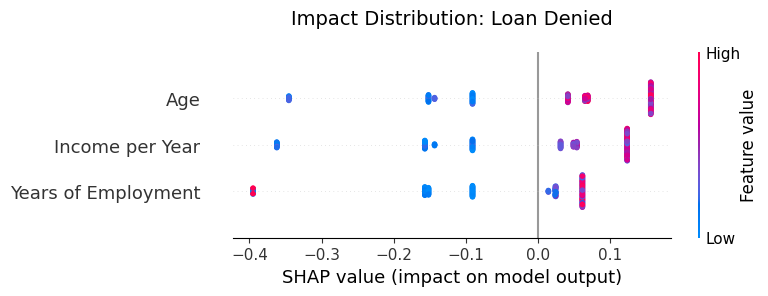

In [2]:

current_shap_raw = np.array(all_shap_dict[0])
s_flat, d_flat, names = get_flattened_data(current_shap_raw)
plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, show=False)
plt.title(f"Impact Distribution: Loan Denied", fontsize=14, pad=20)
plt.show()

### 2. Global Feature Importance
**What is this?** The mean absolute SHAP value for each feature.  
**What to focus on:** The length of the bar. It represents the "global" influence of a feature—how much it moves the prediction on average, regardless of direction.

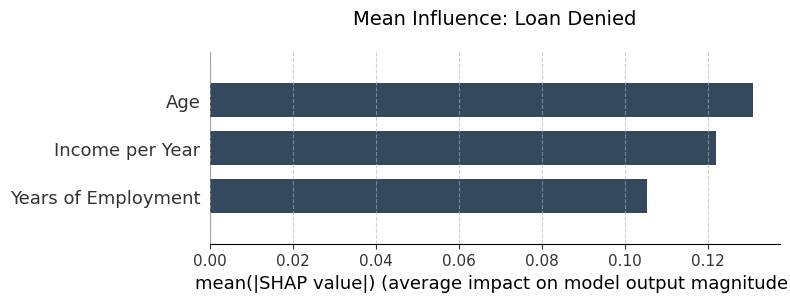

In [3]:

plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, plot_type='bar', show=False, color='#34495e')
plt.title(f"Mean Influence: Loan Denied", fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 4. Focused View: Top 5 Drivers
**What is this?** A high-precision look at the five most critical variables for `Loan Denied`.  
**What to focus on:** The gap between the 1st and 5th feature. If the 1st is much larger, the model is heavily reliant on a single "smoking gun" variable.

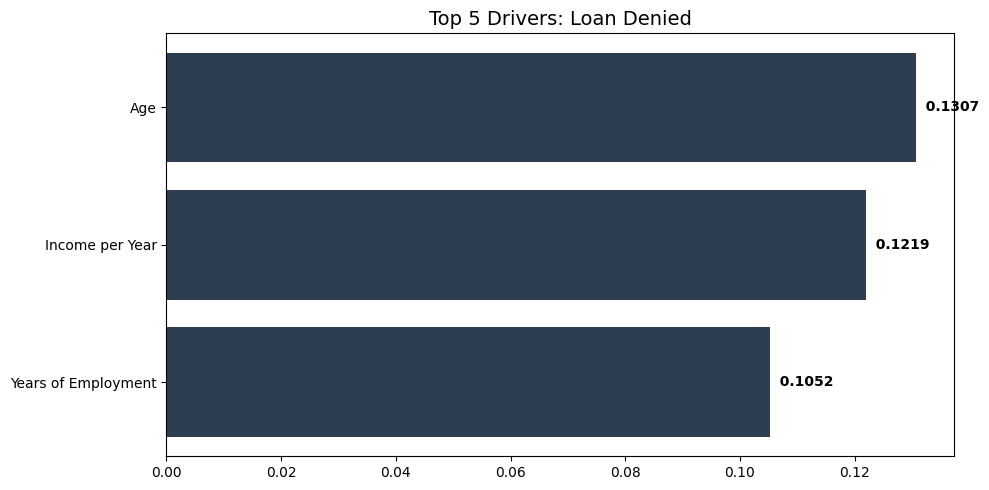

In [4]:

mean_shap = np.abs(s_flat).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[-5:]
plt.figure(figsize=(10, 5))
plt.barh([names[i] for i in sorted_idx], mean_shap[sorted_idx], color='#2c3e50')
plt.title(f"Top 5 Drivers: Loan Denied", fontsize=14)
for i, v in enumerate(mean_shap[sorted_idx]):
    plt.text(v, i, f"  {v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

--- 
# Analysis for: **Loan Approved**

## 🎯 Analysis for Target: `Loan Approved`
---

### 1. Feature Impact Distribution (Beeswarm)
**What is this?** A distribution of SHAP values for every sample in the dataset.  
**What to focus on:** * **Horizontal Position:** Points to the right increase the model output; points to the left decrease it.
* **Color:** Represents the feature value (**Red** is high, **Blue** is low). 
* **Insight:** If Red points are on the right, the feature has a positive correlation with the target.

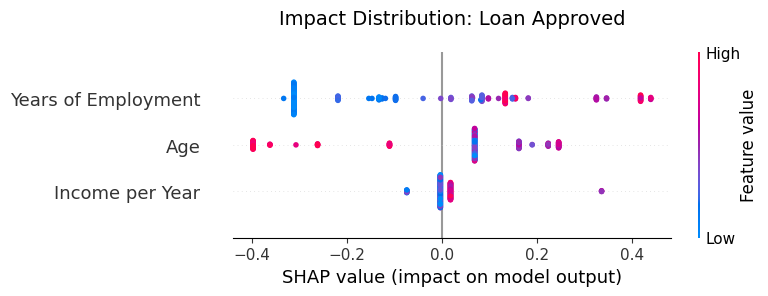

In [5]:

current_shap_raw = np.array(all_shap_dict[1])
s_flat, d_flat, names = get_flattened_data(current_shap_raw)
plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, show=False)
plt.title(f"Impact Distribution: Loan Approved", fontsize=14, pad=20)
plt.show()

### 2. Global Feature Importance
**What is this?** The mean absolute SHAP value for each feature.  
**What to focus on:** The length of the bar. It represents the "global" influence of a feature—how much it moves the prediction on average, regardless of direction.

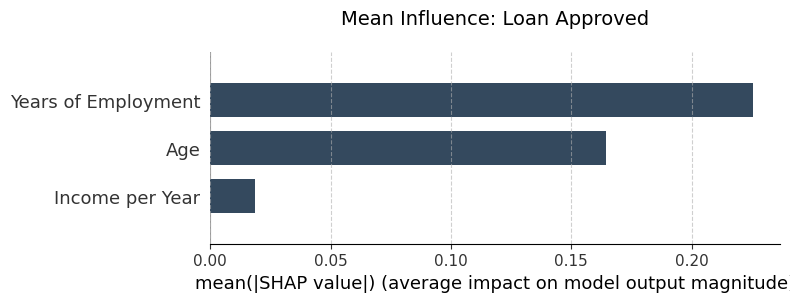

In [6]:

plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, plot_type='bar', show=False, color='#34495e')
plt.title(f"Mean Influence: Loan Approved", fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 4. Focused View: Top 5 Drivers
**What is this?** A high-precision look at the five most critical variables for `Loan Approved`.  
**What to focus on:** The gap between the 1st and 5th feature. If the 1st is much larger, the model is heavily reliant on a single "smoking gun" variable.

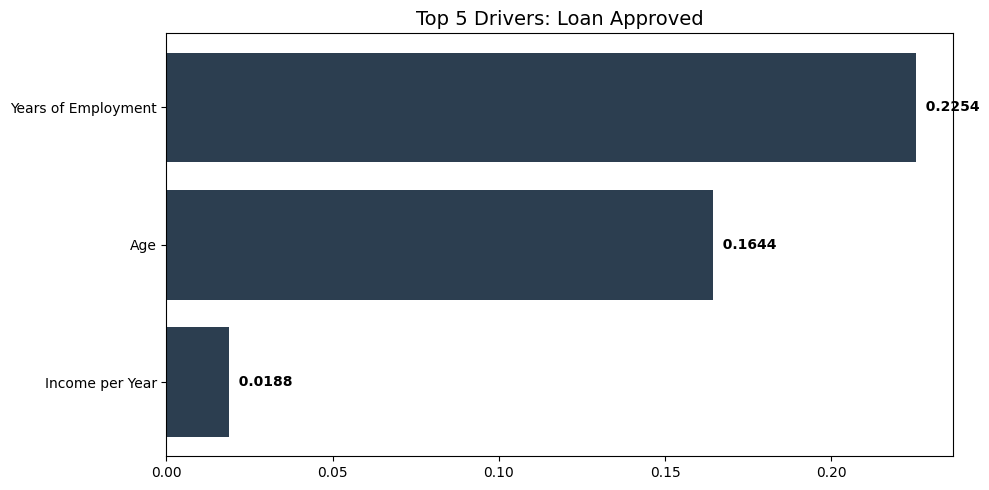

In [7]:

mean_shap = np.abs(s_flat).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[-5:]
plt.figure(figsize=(10, 5))
plt.barh([names[i] for i in sorted_idx], mean_shap[sorted_idx], color='#2c3e50')
plt.title(f"Top 5 Drivers: Loan Approved", fontsize=14)
for i, v in enumerate(mean_shap[sorted_idx]):
    plt.text(v, i, f"  {v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()